# **Preliminary analysis of pedestrian counts - Melbourne CBD**

* **Author**: Quinn Olynyk
* **Date**: 28/07/2026
* **Grain**: Hourly Count
* **Source**: https://discover.data.vic.gov.au/dataset/pedestrian-counting-system-counts-per-hour



## **Loading pedestrian counts (per hour) data.**


In [ ]:
#importing packages
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime as dt
from scipy.signal import find_peaks
import geopandas as gpd
import contextily as ctx
from shapely import wkt
import json
from shapely.geometry import shape
from shapely.geometry import box
!pip install contextily

import warnings
warnings.filterwarnings("ignore", message="Several features with id")

**Implementing data sources**

In [111]:

# Pedestrian Counting System - Counts per Hour
count_url = "https://data.melbourne.vic.gov.au/api/v2/catalog/datasets/pedestrian-counting-system-monthly-counts-per-hour/exports/csv?delimiter=%2C"

# Pedestrian Counting System - Sensor Locations
sensor_url = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/pedestrian-counting-system-sensor-locations/exports/csv?lang=en&timezone=Australia%2FMelbourne&use_labels=true&delimiter=%2C"

# Bicycle Network Data
bicycle_url = "https://data.melbourne.vic.gov.au/api/v2/catalog/datasets/bicycle-network/exports/geojson"

ped = pd.read_csv(count_url)
sensor_locations = pd.read_csv(sensor_url)
network = gpd.read_file(bicycle_url)

**Evaluation and cleaning**

In [92]:
# Data Head
ped.head(5)

,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location
0,44120260827,44,2026-08-27,1,3,1,4,UM3_T,"-37.79698741, 144.96441306"
1,67120260827,67,2026-08-27,1,6,5,11,FLDegS_T,"-37.81688755, 144.96562569"
2,1020260827,1,2026-08-27,0,22,37,59,Bou292_T,"-37.81349441, 144.96515323"
3,25320260827,25,2026-08-27,3,0,2,2,MCEC_T,"-37.82401776, 144.95604426"
4,141120260827,141,2026-08-27,1,13,11,24,474Fl_T,"-37.81997273, 144.95834911"


In [93]:
# Row Count
ped.shape
# 9 columns, 1,610,972 observations (rows)

(1618635, 9)

In [94]:
# Scanning for nulls
ped.isna().sum()
# 26051 Null values for {pedestriancount, location}

,0
id,0
location_id,0
sensing_date,0
hourday,0
direction_1,0
direction_2,0
pedestriancount,0
sensor_name,24039
location,24039


In [98]:
#isolating to location_id with valid rows.
ped2 = ped[ped['sensor_name'].notna()].copy()
ped2.head()

,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location
0,44120260827,44,2026-08-27,1,3,1,4,UM3_T,"-37.79698741, 144.96441306"
1,67120260827,67,2026-08-27,1,6,5,11,FLDegS_T,"-37.81688755, 144.96562569"
2,1020260827,1,2026-08-27,0,22,37,59,Bou292_T,"-37.81349441, 144.96515323"
3,25320260827,25,2026-08-27,3,0,2,2,MCEC_T,"-37.82401776, 144.95604426"
4,141120260827,141,2026-08-27,1,13,11,24,474Fl_T,"-37.81997273, 144.95834911"


In [102]:
# Adding time column to allow for yearly breakdown
ped2['year'] = pd.DatetimeIndex(ped2['sensing_date']).year
ped2['month'] = pd.DatetimeIndex(ped2['sensing_date']).month
ped2['day'] = pd.DatetimeIndex(ped2['sensing_date']).day
# Splitting location into latitude and longitude
ped2['Latitude'] = ped2['location'].str.split(',').str[0]
ped2['Longitude'] = ped2['location'].str.split(',').str[1]
ped2.head()

,id,location_id,sensing_date,hourday,direction_1,direction_2,pedestriancount,sensor_name,location,year,month,day,Latitude,Longitude
0,44120260827,44,2026-08-27,1,3,1,4,UM3_T,"-37.79698741, 144.96441306",2026,8,27,-37.79698741,144.96441306
1,67120260827,67,2026-08-27,1,6,5,11,FLDegS_T,"-37.81688755, 144.96562569",2026,8,27,-37.81688755,144.96562569
2,1020260827,1,2026-08-27,0,22,37,59,Bou292_T,"-37.81349441, 144.96515323",2026,8,27,-37.81349441,144.96515323
3,25320260827,25,2026-08-27,3,0,2,2,MCEC_T,"-37.82401776, 144.95604426",2026,8,27,-37.82401776,144.95604426
4,141120260827,141,2026-08-27,1,13,11,24,474Fl_T,"-37.81997273, 144.95834911",2026,8,27,-37.81997273,144.95834911


## **Breaking down for 2025**

In [96]:
ped_2025 = ped2[ped2['year'] == 2025]
ped_2025.head()

,ID,Location_ID,Sensing_Date,HourDay,Direction_1,Direction_2,Total_of_Directions,Sensor_Name,Location,year,month,day,Latitude,Longitude
535033,1241720251231,124,2025-12-31,17,4,8,12,BirBridge_T,"-37.81757416, 144.97329934",2025,12,31,-37.81757416,144.97329934
535034,25420251231,25,2025-12-31,4,6,4,10,MCEC_T,"-37.82401776, 144.95604426",2025,12,31,-37.82401776,144.95604426
535035,49920251231,49,2025-12-31,9,151,138,289,Eli501_T,"-37.80730068, 144.95956055",2025,12,31,-37.80730068,144.95956055
535036,1432220251231,143,2025-12-31,22,585,1093,1678,Spencer_T,"-37.821728, 144.95557015",2025,12,31,-37.821728,144.95557015
535037,1841120251231,184,2025-12-31,11,1017,868,1885,Eli124_T,"-37.81512416, 144.96371988",2025,12,31,-37.81512416,144.96371988


In [97]:
ped_2025['Total_of_Directions'].describe()

,Total_of_Directions
count,799469.000000
mean,394.801311
std,590.351068
min,0.000000
25%,38.000000
50%,161.000000
75%,488.000000
max,11113.000000


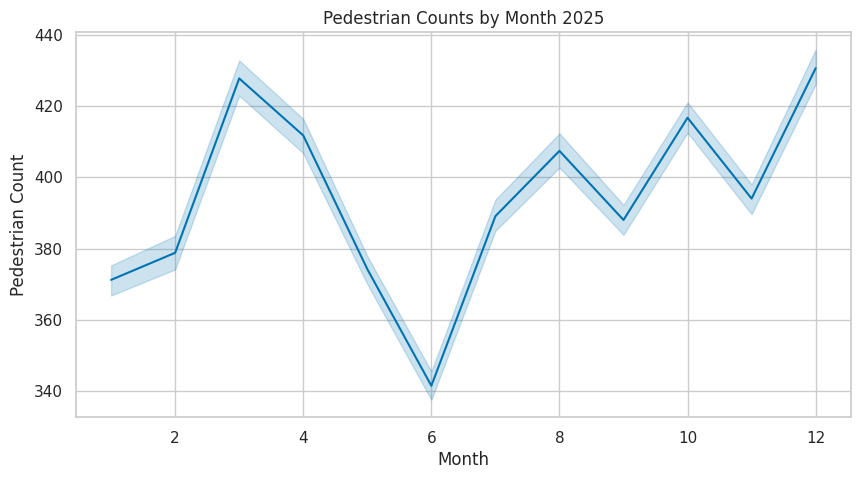

In [100]:
#visualising pedestrian counts in 2025 as a time-series.
plt.figure(figsize = (10,5))
#Plotting
sns.lineplot(data = ped_2025, x = 'month', y = 'Total_of_Directions')
plt.title("Pedestrian Counts by Month 2025")
plt.xlabel("Month")
plt.ylabel("Pedestrian Count")
# Implementing
plt.show()

**Comparing against other years**

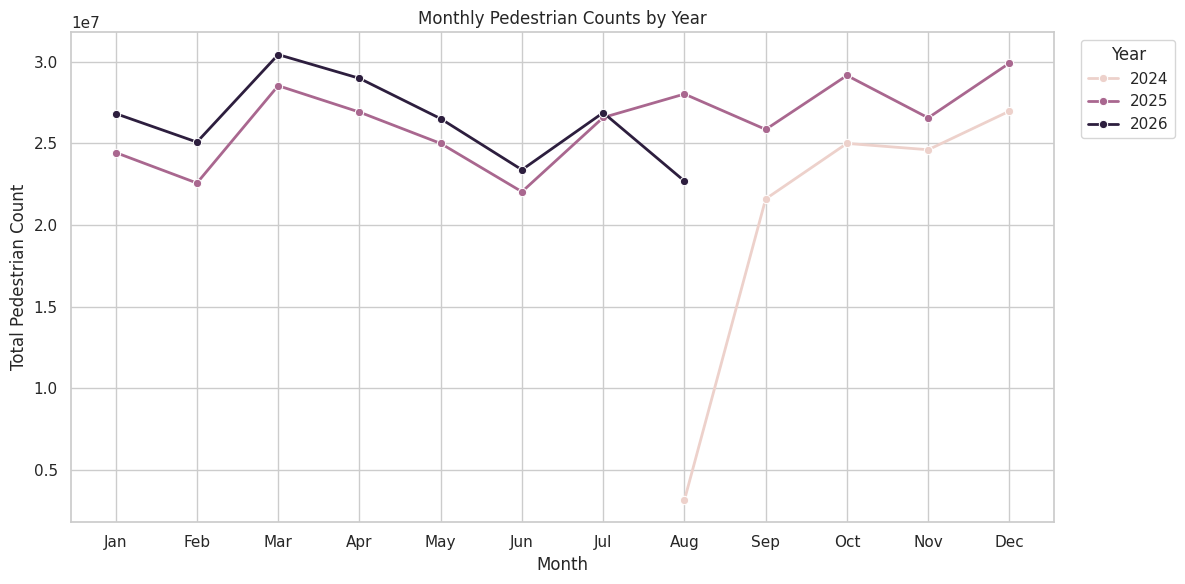

In [114]:
# Colour scheme
sns.set_theme(style="whitegrid", palette="colorblind")

# Years in full range
years_to_plot = [2022, 2023, 2024, 2025, 2026]

# Filter the source data
ped_yearly = ped2[
    ped2["year"].isin(years_to_plot)
].copy()

# Ensure pedestrian counts are numeric
ped_yearly["Total_of_Directions"] = pd.to_numeric(
    ped_yearly["pedestriancount"],
    errors="coerce"
)

# Aggregate total pedestrian counts by year and month
monthly_counts = (
    ped_yearly
    .groupby(["year", "month"], as_index=False)["Total_of_Directions"]
    .sum()
)

# Chronological order for clarity
monthly_counts["month"] = pd.to_numeric(
    monthly_counts["month"],
    errors="coerce"
)

monthly_counts = monthly_counts.dropna(subset=["month"])
monthly_counts["month"] = monthly_counts["month"].astype(int)

monthly_counts = monthly_counts.sort_values(
    ["year", "month"]
)

# Establishing chart
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_counts,
    x="month",
    y="Total_of_Directions",
    hue="year",
    hue_order=years_to_plot,
    marker="o",
    linewidth=2
)

# Formatting
plt.title("Monthly Pedestrian Counts by Year")
plt.xlabel("Month")
plt.ylabel("Total Pedestrian Count")
plt.xticks(
    ticks=range(1, 13),
    labels=[
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]
)

plt.legend(
    title="Year",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## **Pedestrian Density Plot**

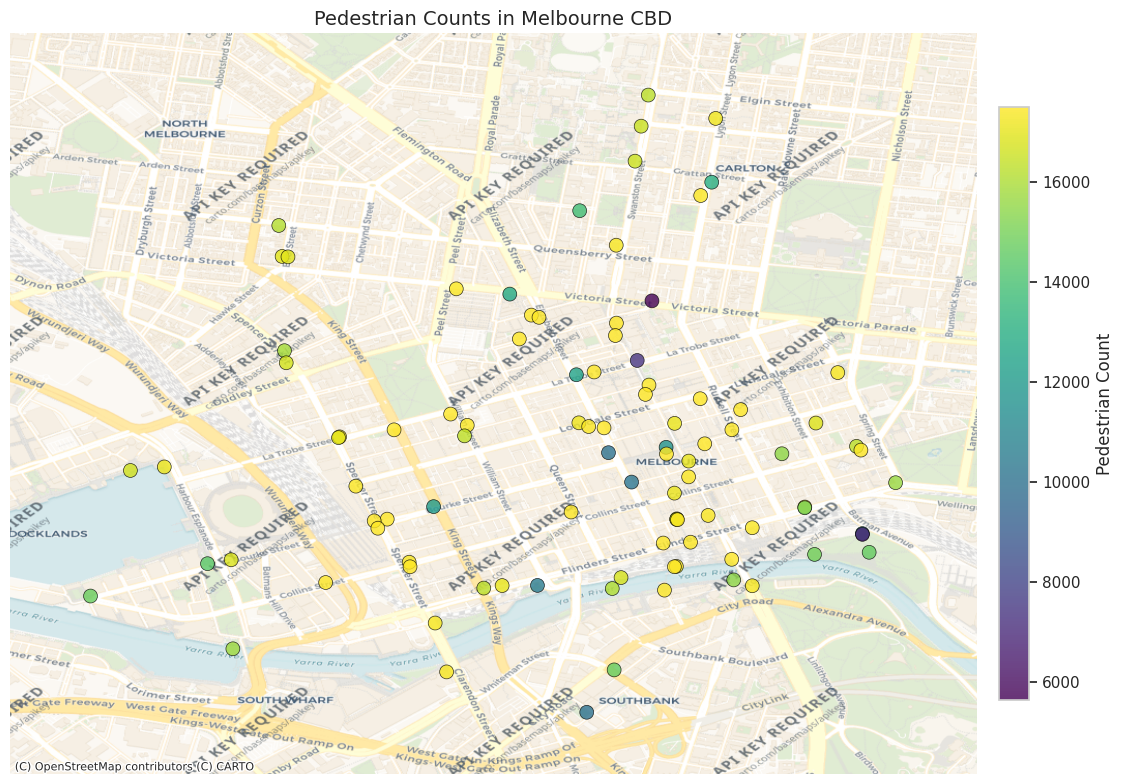

In [104]:

# Aggregate pedestrian records
data = (
    ped2
    .groupby(['Latitude', 'Longitude'])
    .size()
    .reset_index(name='pedestriancount')
)

df = pd.DataFrame(data)

# Clean coordinates
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

df = df.dropna(
    subset=['Latitude', 'Longitude', 'pedestriancount']
)

df = df[
    df['Latitude'].between(-90, 90)
    & df['Longitude'].between(-180, 180)
].copy()

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df['Longitude'],
        df['Latitude']
    ),
    crs='EPSG:4326'
)

# Filter to Melbourne CBD
melbourne_cbd = gdf[
    gdf['Longitude'].between(144.94, 144.99)
    & gdf['Latitude'].between(-37.83, -37.79)
].copy()

# Convert to Web Mercator for contextily
melbourne_cbd = melbourne_cbd.to_crs(epsg=3857)

# Create plot
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    melbourne_cbd.geometry.x,
    melbourne_cbd.geometry.y,
    c=melbourne_cbd['pedestriancount'],
    cmap='viridis',
    s=100,
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8,
    zorder=2
)

# Add OpenStreetMap background
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Voyager,
    zorder=0
)

# Automatically focus around the CBD data points
if not melbourne_cbd.empty:
    minx, miny, maxx, maxy = melbourne_cbd.total_bounds

    x_padding = (maxx - minx) * 0.1
    y_padding = (maxy - miny) * 0.1

    ax.set_xlim(minx - x_padding, maxx + x_padding)
    ax.set_ylim(miny - y_padding, maxy + y_padding)

colour_bar = plt.colorbar(
    scatter,
    ax=ax,
    shrink=0.8,
    pad=0.02
)

colour_bar.set_label('Pedestrian Count')

ax.set_title(
    'Pedestrian Counts in Melbourne CBD',
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [106]:
# Isolating Location id's with high pedestrian counts
high_count_locations = (
    ped2
    .groupby('location_id', as_index=False)['pedestriancount']
    .sum()
    .sort_values('pedestriancount', ascending=False)
    .head(10)
)

print(high_count_locations)

    location_id  pedestriancount
3             4         26564535
29           41         26155824
24           35         23037723
49           66         21320246
60           84         20954652
2             3         19721448
4             5         19112342
18           24         15683480
35           47         15622838
33           45         13407343


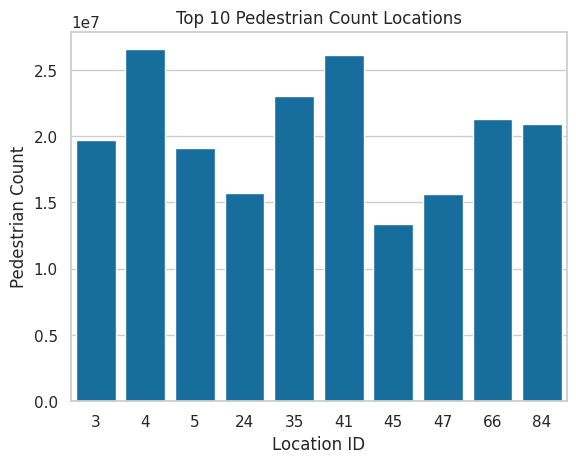

In [107]:
sns.barplot(data = high_count_locations, x = 'location_id', y = 'pedestriancount')
plt.title("Top 10 Pedestrian Count Locations")
plt.xlabel("Location ID")
plt.ylabel("Pedestrian Count")
plt.show()

**High Pedestrian Counts timeline**

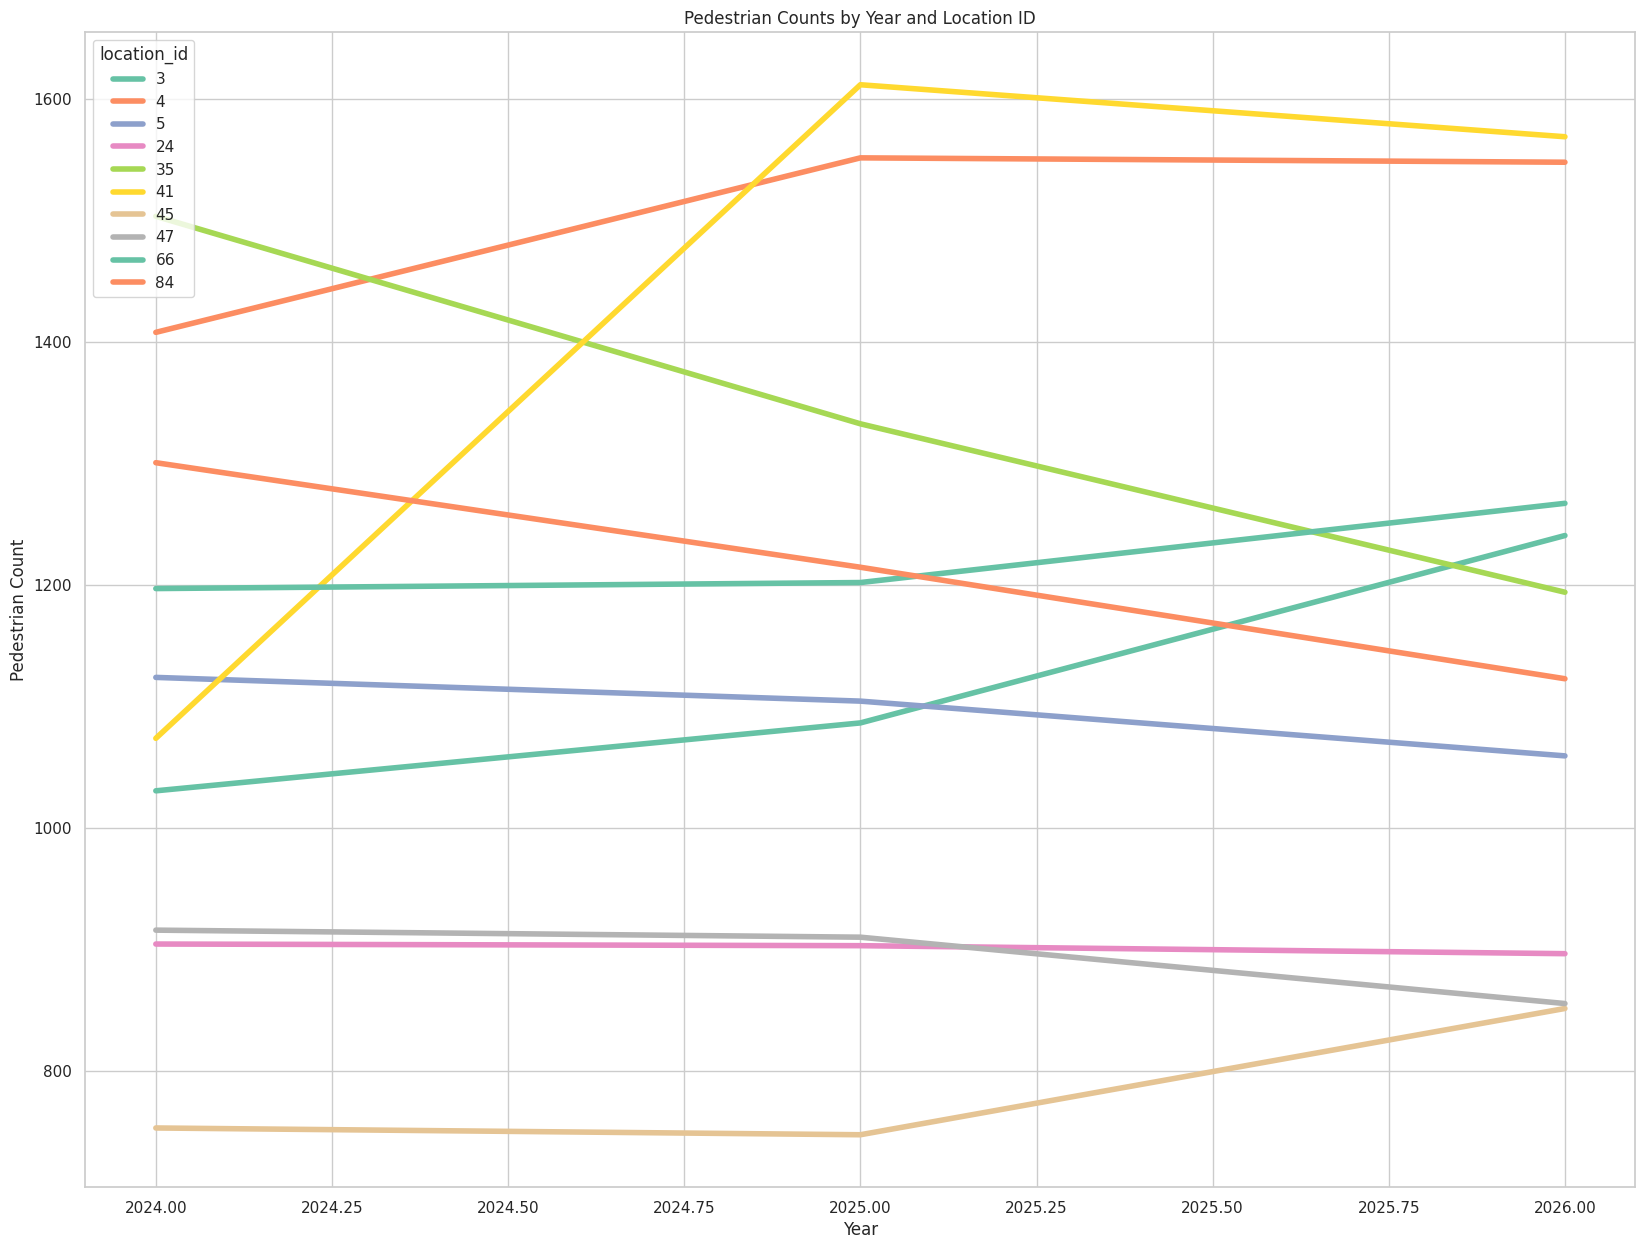

In [108]:
# We will go back to the original pedestrian data and filter using the ID's observed.
ped_high_count = ped2[ped2['location_id'].isin(high_count_locations['location_id'])]
ped_high_count.head()

#plotting bar graphs to compare each ID across years.
# x = year, y = pedestrian count, legend = ID.
plt.figure(figsize = (20,15))
#Plotting
ax = sns.lineplot(data = ped_high_count, x = 'year', y = 'pedestriancount', hue = 'location_id',
             palette="Set2", errorbar=None, linewidth=4)
plt.title("Pedestrian Counts by Year and Location ID")
plt.xlabel("Year")
plt.ylabel("Pedestrian Count")
# Implementing
plt.show()

In [112]:
# Linking Location ID's to true location labels.
sensor_locations.head()

,Location_ID,Sensor_Description,Sensor_Name,Installation_Date,Note,Location_Type,Status,Direction_1,Direction_2,Latitude,Longitude,Location
0,3,Melbourne Central,Swa295_T,2009-03-25,NaN,Outdoor,A,North,South,-37.811015,144.964295,"-37.81101524, 144.96429485"
1,5,Princes Bridge,PriNW_T,2009-03-26,Replace with: 00:6e:02:01:9e:54,Outdoor,A,North,South,-37.818742,144.967877,"-37.81874249, 144.96787656"
2,9,Southern Cross Station,Col700_T,2009-03-23,NaN,Outdoor,A,East,West,-37.819830,144.951026,"-37.81982992, 144.95102555"
3,11,Docklands Waterfront City Building Side,WatCit_T,2009-01-20,Device has been replaced with new sensor on 22...,Outdoor,A,East,West,-37.815667,144.939744,"-37.81566651, 144.93974366"
4,12,New Quay,NewQ_T,2009-01-21,NaN,Outdoor,A,East,West,-37.814580,144.942924,"-37.81457988, 144.94292398"


In [115]:
# generating top-10 highest foot-traffic locations

all_high_count_data = []

for i in high_count_locations['location_id']:
  # Get the sensor information for the current location_id 'i'
  k = sensor_locations[sensor_locations['Location_ID'] == i].copy()
  current_ped_count = high_count_locations[high_count_locations['location_id'] == i]['pedestriancount'].iloc[0]
  k['pedestriancount'] = current_ped_count
  k_to_print = k[['Location_ID','Sensor_Description','pedestriancount']]
  # Append the DataFrame for the current location to the list
  all_high_count_data.append(k_to_print)
# Concatenate all individual DataFrames into one large DataFrame
final_df_to_print = pd.concat(all_high_count_data, ignore_index=True)
final_df_to_print.columns = ['ID', 'Name', 'count']
print(final_df_to_print.to_string(index=False))
# Extracting location names (this will now contain all names from the top locations)
high_pedestrian_locations = final_df_to_print['Name']

 ID                                             Name    count
  4                                 Town Hall (West) 26564535
 41                   Flinders La-Swanston St (West) 26155824
 35                              Southbank Promenade 23037723
 66              QV2 Apartments, 300 Swanston Street 21320246
 84 Elizabeth St - Flinders St (East) - New footpath 20954652
  3                                Melbourne Central 19721448
  5                                   Princes Bridge 19112342
 24                    Spencer St-Collins St (North) 15683480
 47            Melbourne Central-Elizabeth St (East) 15622838
 45             Little Collins St-Swanston St (East) 13407343


# **Generating a density map with bicycle network included**

**Bicycle network pre-implementation analysis**

In [117]:
if network.crs is None:
    network = network.set_crs('EPSG:4326')
network = network.to_crs(epsg=3857)
network_lines = network[network.geom_type.isin(['LineString', 'MultiLineString'])]

network.head()

,geo_point_2d,objectid,roadclass,width,oneway,management,direction,shape_length,description,geometry
0,"{'lon': 144.93118404125, 'lat': -37.7990734515...",74,91,0,None,Connector,B,3.745864,Entrance connecctor,"LINESTRING (16133664.999 -4551082.683, 1613366..."
1,"{'lon': 144.96053695175, 'lat': -37.8121545244}",85,91,0,None,Connector,B,3.030180,Entrance connecctor,"LINESTRING (16136931.357 -4552924.081, 1613693..."
2,"{'lon': 144.96663793525, 'lat': -37.79756635265}",92,91,0,None,Connector,B,1.972702,Entrance connecctor,"LINESTRING (16137612.146 -4550869.306, 1613761..."
3,"{'lon': 144.9745210616, 'lat': -37.79494358124...",93,91,0,None,Connector,B,3.914924,Entrance connecctor,"LINESTRING (16138489.496 -4550501.037, 1613849..."
4,"{'lon': 144.96168858775, 'lat': -37.8192308447...",126,91,0,None,Connector,B,21.793443,Entrance connecctor,"LINESTRING (16137066.102 -4553933.562, 1613705..."


In [118]:
# Unique descriptions
bnetwork_desc = network['description'].unique()
#counts
bnetwork_desc_count = network['description'].value_counts()
print(tabulate(pd.DataFrame(bnetwork_desc_count)))

--------------------------------------------------  -----
Centroid connector                                  53815
Entrance connecctor                                 23809
Local Road                                          18498
Standard bicycle lane                                4966
Interesection                                        2651
Arterial  Road                                       2199
Shared Path                                          1849
Walking Track                                        1835
Collector Road                                       1399
Sub-Arterial Road                                    1360
Traffic protecting chevron                            745
Total protecte chevron (protect from dooring and *    647
dooring protecting chevron                            510
2wd Road                                              462
Shared Intersection (Bike Lane)                       377
Kerb side physically separated                        276
Sharrow       

**Mapping network types for La Trobe St and Lonsdale St**

In [120]:
# STEP 1 — Load sensor metadata (names, coordinates, status)

sensor_locations = pd.read_csv('/content/pedestrian-counting-system-sensor-locations.csv')
sensor_locations = sensor_locations[sensor_locations['Status'] == 'A']  # active sensors only

sensor_locations = sensor_locations.rename(columns={
    'Location_ID': 'location_id',
    'Sensor_Description': 'sensor_description',
    'Latitude': 'sensor_lat',
    'Longitude': 'sensor_lon'
})[['location_id', 'sensor_description', 'sensor_lat', 'sensor_lon']]

# STEP 2 — Join pedestrian counts (ped2) to sensor metadata
ped_with_names = ped2.merge(sensor_locations, on='location_id', how='left')

# Sanity check — flag any location_ids in ped2 with no metadata match
unmatched = ped_with_names[ped_with_names['sensor_description'].isna()]['location_id'].unique()
if len(unmatched) > 0:
    print(f"Warning: {len(unmatched)} location_id(s) in ped2 have no match in sensor metadata: {unmatched}")

# STEP 3 — Filter to Lonsdale St and La Trobe St
# Use if in as location descriptions include 'lonsdale st' and 'la trobe st', not set as them!
def assign_group(desc):
    if pd.isna(desc):
        return None
    d = desc.lower()
    if 'little lonsdale' in d:
        return None  # exclude — different street
    if 'lonsdale' in d:
        return 'Lonsdale St'
    if 'la trobe' in d or 'latrobe' in d:
        return 'La Trobe St'
    return None

ped_with_names['street_group'] = ped_with_names['sensor_description'].apply(assign_group)

ped_target = ped_with_names.dropna(subset=['street_group']).copy()

print(f"Matched {ped_target['location_id'].nunique()} unique sensors across {len(ped_target)} pedestrian records:")
print(ped_target[['location_id', 'sensor_description', 'street_group']].drop_duplicates())

# STEP 4 — Build GeoDataFrame of unique sensor locations

target_gdf = ped_target[['location_id', 'sensor_description', 'street_group', 'sensor_lat', 'sensor_lon']].drop_duplicates(subset='location_id')

target_gdf = target_gdf.dropna(subset=['sensor_lat', 'sensor_lon']) #cleaning na's
#GeoDataFrame
target_gdf = gpd.GeoDataFrame(
    target_gdf,
    geometry=gpd.points_from_xy(target_gdf['sensor_lon'], target_gdf['sensor_lat']),
    crs='EPSG:4326'
).to_crs(epsg=3857)

# STEP 5 — Merge sensors within the same street group

merged_locations = target_gdf.dissolve(by='street_group').reset_index()

# STEP 6 — Buffer around each merged location

buffer_distance = 100  # metres

merged_locations['buffer'] = merged_locations.geometry.buffer(buffer_distance)
merged_buffers = merged_locations.set_geometry('buffer')

# STEP 7 — Intersect with bike network
# network_lines already exists from above!

bike_near_locations = gpd.sjoin(
    network_lines,
    merged_buffers[['street_group', 'buffer']],
    how='inner',
    predicate='intersects'
)

# STEP 8 — Summarize bike network types per location.

type_column = 'description'  # location description.
summary = (
    bike_near_locations
    .groupby('street_group')[type_column]
    .value_counts()
    .rename('segment_count')
    .reset_index()
)

# Classify each description as bike-specific or general road context

bike_specific_types = [
    'Standard bicycle lane', 'Peak hour bike lane', 'Sharrow',
    'Kerb side physically separated', 'Total protecte chevron (protect from dooring and *',
    'dooring protecting chevron', 'Shared Intersection (Bike Lane)'
]

summary['category'] = summary['description'].apply(
    lambda d: 'Bike Infrastructure' if d in bike_specific_types else 'General Road/Path Context'
)

# Clean, sorted table — bike infrastructure only, side by side by street!

bike_summary = summary[summary['category'] == 'Bike Infrastructure']

pivot_table = bike_summary.pivot_table(
    index='description',
    columns='street_group',
    values='segment_count',
    fill_value=0
).astype(int)

# Add a total column and sort by it, most common infrastructure first
pivot_table['Total'] = pivot_table.sum(axis=1)
pivot_table = pivot_table.sort_values('Total', ascending=False)

print("Bike Infrastructure — Segment Counts by Street")
print(pivot_table.to_string())

Matched 10 unique sensors across 173663 pedestrian records:
    location_id                                 sensor_description  \
6            52                   Elizabeth St-Lonsdale St (South)   
21          132  I-Hub Corner of King Street and Latrobe Street...   
25           62                                La Trobe St (North)   
40          164               I-Hub 526 La Trobe Street (Footpath)   
54           40                       Lonsdale St-Spring St (West)   
61           56                 Lonsdale St - Elizabeth St (North)   
62          167               I-Hub 526 La Trobe Street (Crossing)   
72          133  I-Hub Southern Cross Station - Lonsdale Street...   
75           30                                Lonsdale St (South)   
81          109                    La Trobe St- William St (South)   

   street_group  
6   Lonsdale St  
21  La Trobe St  
25  La Trobe St  
40  La Trobe St  
54  Lonsdale St  
61  Lonsdale St  
62  La Trobe St  
72  Lonsdale St  
75  Lon

**Laying over pedestrian density map**

In [121]:
# --- Build a grid over the CBD ---
minx, miny, maxx, maxy = melbourne_cbd.total_bounds  # use pedestrian network bounds

cell_size = 75  # metres (since we're in EPSG:3857) — tune this: smaller = finer detail, noisier
x_edges = np.arange(minx, maxx + cell_size, cell_size)
y_edges = np.arange(miny, maxy + cell_size, cell_size)

grid_cells = []
for x0 in x_edges[:-1]:
    for y0 in y_edges[:-1]:
        grid_cells.append(box(x0, y0, x0 + cell_size, y0 + cell_size))

grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs=network_lines.crs)

# --- Compute bike network length within each grid cell ---
# Clip network lines to each cell and sum length (overlay is the vectorised way to do this)
network_clipped = gpd.overlay(
    network_lines[['geometry']],
    grid.reset_index().rename(columns={'index': 'cell_id'}),
    how='intersection'
)
network_clipped['seg_length'] = network_clipped.geometry.length

density_by_cell = network_clipped.groupby('cell_id')['seg_length'].sum()

grid['bike_density'] = grid.index.map(density_by_cell).fillna(0)

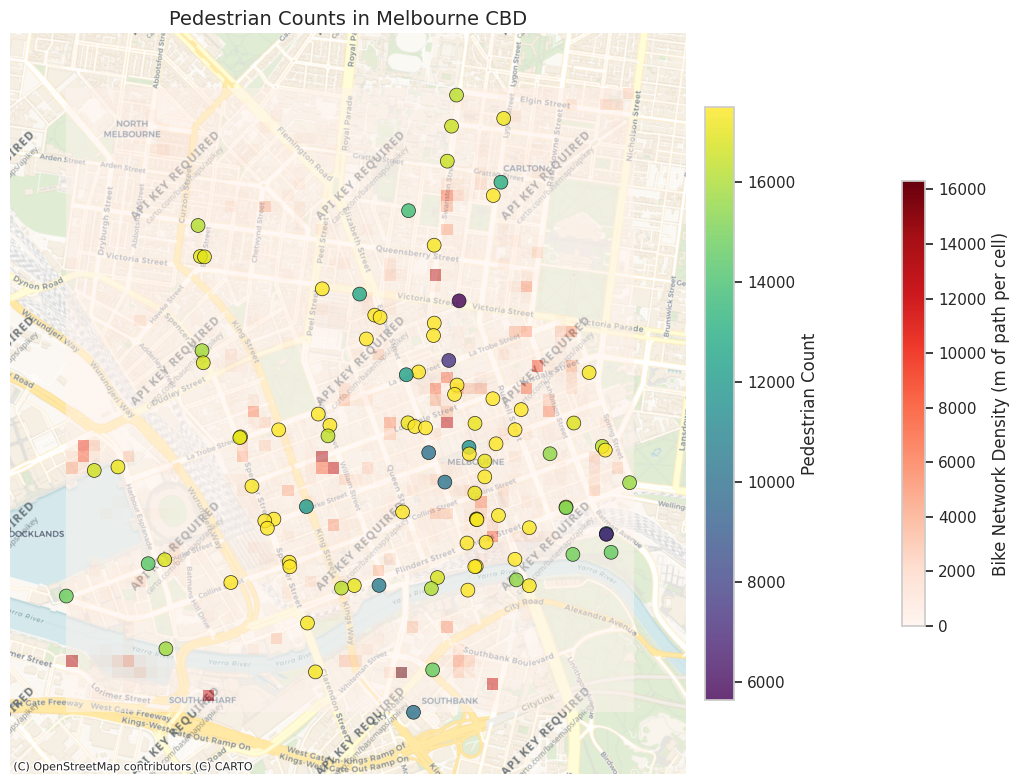

In [122]:

#network
network = gpd.read_file("/content/bicycle-network.geojson")
if network.crs is None:
    network = network.set_crs('EPSG:4326')
network = network.to_crs(epsg=3857)
network_lines = network[network.geom_type.isin(['LineString', 'MultiLineString'])]

# Aggregate pedestrian records
data = (
    ped2
    .groupby(['Latitude', 'Longitude'])
    .size()
    .reset_index(name='pedestriancount')
)

df = pd.DataFrame(data)

# Clean coordinates
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

df = df.dropna(
    subset=['Latitude', 'Longitude', 'pedestriancount']
)

df = df[
    df['Latitude'].between(-90, 90)
    & df['Longitude'].between(-180, 180)
].copy()

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(
        df['Longitude'],
        df['Latitude']
    ),
    crs='EPSG:4326'
)

# Melbourne CBD Filter
melbourne_cbd = gdf[
    gdf['Longitude'].between(144.94, 144.99)
    & gdf['Latitude'].between(-37.83, -37.79)
].copy()

# Convert to Web Mercator for contextily
melbourne_cbd = melbourne_cbd.to_crs(epsg=3857)

# Create plot
fig, ax = plt.subplots(figsize=(12, 8))

#Bicycle network density
grid.plot(
    column='bike_density',
    ax=ax,
    cmap='Reds',
    alpha=0.5,
    edgecolor='none',
    zorder=1,
    legend=True,
    legend_kwds={'label': 'Bike Network Density (m of path per cell)', 'shrink': 0.6})

scatter = ax.scatter(
    melbourne_cbd.geometry.x,
    melbourne_cbd.geometry.y,
    c=melbourne_cbd['pedestriancount'],
    cmap='viridis',
    s=100,
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8,
    zorder=2
)

# Add OpenStreetMap background
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Voyager, zorder=0)

# Automatically focus around the CBD data points
if not melbourne_cbd.empty:
    minx, miny, maxx, maxy = melbourne_cbd.total_bounds

    x_padding = (maxx - minx) * 0.1
    y_padding = (maxy - miny) * 0.1

    ax.set_xlim(minx - x_padding, maxx + x_padding)
    ax.set_ylim(miny - y_padding, maxy + y_padding)

colour_bar = plt.colorbar(
    scatter,
    ax=ax,
    shrink=0.8,
    pad=0.02
)

colour_bar.set_label('Pedestrian Count')

ax.set_title(
    'Pedestrian Counts in Melbourne CBD',
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

**Finding nearest sensor locations to high bicycle network density areas**

In [123]:
# We want to map out spots with high bicycle network density and then deduce which sensors are closest to these locales
# --- Attach each sensor's grid cell (and its bike density) via spatial join ---
sensors_with_density = gpd.sjoin(
    melbourne_cbd,
    grid[['geometry', 'bike_density']],
    how='left',
    predicate='within'
)

# Some sensors might sit exactly on a cell boundary and get dropped/duplicated —
# check for that:
print(f"Original sensors: {len(melbourne_cbd)}, after join: {len(sensors_with_density)}")
# all sensors captured!

Original sensors: 96, after join: 96


                 pedestriancount  bike_density
pedestriancount       100.000000      9.857587
bike_density            9.857587    100.000000


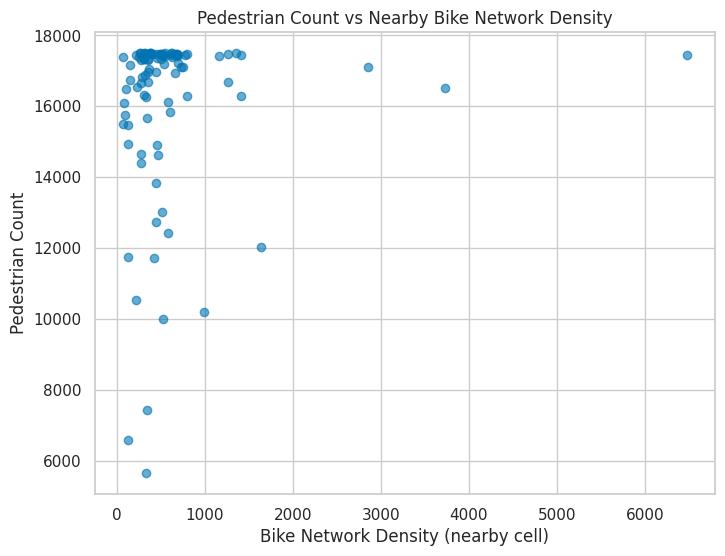

In [124]:
#testing correlation between pedestrian count density and bike network density.
correlation = sensors_with_density[['pedestriancount', 'bike_density']].corr()
print(f'{correlation*100}') # Extremely low correlation.

# and visually:
plt.figure(figsize=(8,6))
plt.scatter(sensors_with_density['bike_density'], sensors_with_density['pedestriancount'], alpha=0.6)
plt.xlabel('Bike Network Density (nearby cell)')
plt.ylabel('Pedestrian Count')
plt.title('Pedestrian Count vs Nearby Bike Network Density')
# Final implement
plt.show()